# Papyri Economic EDA

Exploratory analysis of Roman Egypt documentary papyri for behavioral economics signal.

**Data sources:**
- `processed_data/papyri/apis_combined.csv` — 9,832 docs from 29 APIS institutions; 2,354 with English translation
- `processed_data/papyri/p.oxy_parsed.csv` — 3,451 P.Oxy DDB EpiDoc transcriptions
- `processed_data/papyri/p.mich_parsed.csv` — 818 P.Mich DDB EpiDoc transcriptions

**Research questions:**
1. What economic transaction types are present, and in what proportions?
2. Is there evidence of loss/complaint framing (loss aversion signal)?
3. What grain and commodity prices appear — and do they vary in ways consistent with reference-price anchoring?
4. What interest rates appear in loan documents?
5. What is the temporal distribution of economic documents?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from collections import Counter

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 50)

# Load data
apis = pd.read_csv('../processed_data/papyri/apis_combined.csv')
poxy = pd.read_csv('../processed_data/papyri/p.oxy_parsed.csv')
pmich = pd.read_csv('../processed_data/papyri/p.mich_parsed.csv')

print(f'APIS total:       {len(apis):,} docs | {apis["has_translation"].sum():,} translated')
print(f'P.Oxy total:      {len(poxy):,} docs')
print(f'P.Mich total:     {len(pmich):,} docs')

APIS total:       9,832 docs | 2,354 translated
P.Oxy total:      3,451 docs
P.Mich total:     818 docs


## 1. Translation coverage by institution

In [2]:
coverage = (
    apis.groupby('institution')
    .agg(docs=('doc_id','count'), translated=('has_translation','sum'))
    .assign(pct=lambda x: (100*x.translated/x.docs).round(1))
    .sort_values('translated', ascending=False)
)
coverage[coverage.translated > 0]

,docs,translated,pct
institution,,,
michigan,822,804,97.8
berkeley,757,360,47.6
chicago,253,253,100.0
berenike,261,205,78.5
princeton,885,159,18.0
oslo,150,134,89.3
wisconsin,101,90,89.1
leidenpapinst,199,73,36.7
petra,88,55,62.5


## 2. Temporal distribution of translated documents

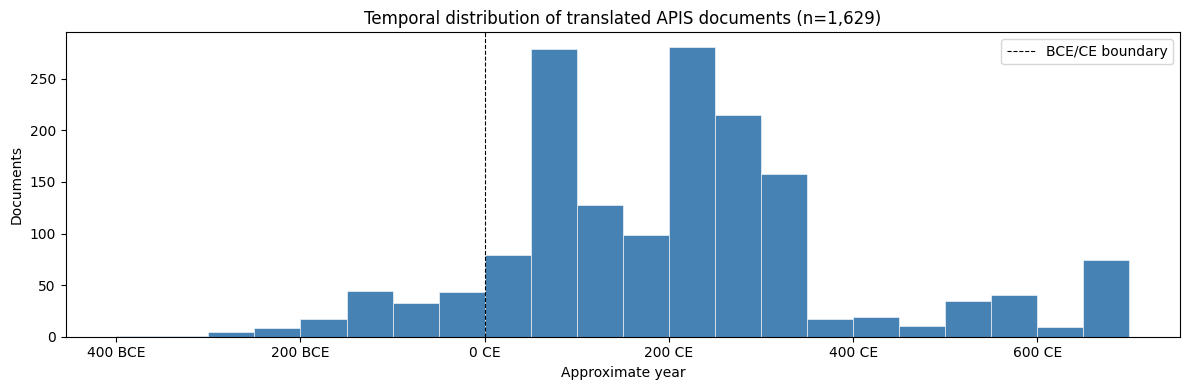

Dated: 1,629 / 2,354 (69%)


In [3]:
translated = apis[apis.has_translation].copy()
dated = translated[translated.date_year_approx.notna()].copy()
dated['date_year_approx'] = dated['date_year_approx'].astype(int)

fig, ax = plt.subplots(figsize=(12, 4))
bins = range(-400, 750, 50)
ax.hist(dated['date_year_approx'], bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.8, linestyle='--', label='BCE/CE boundary')
ax.set_xlabel('Approximate year')
ax.set_ylabel('Documents')
ax.set_title(f'Temporal distribution of translated APIS documents (n={len(dated):,})')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x))} {"BCE" if x < 0 else "CE"}'))
ax.legend()
plt.tight_layout()
plt.show()
print(f'Dated: {len(dated):,} / {len(translated):,} ({100*len(dated)/len(translated):.0f}%)')

## 3. Document type / genre distribution

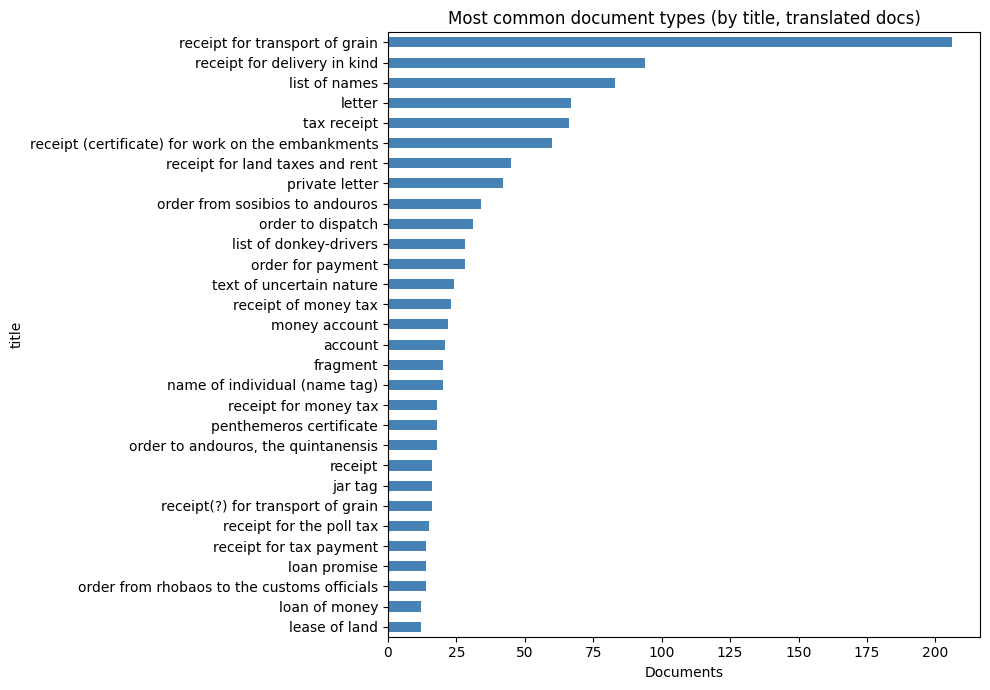

In [4]:
# Use title as proxy for document type
title_counts = translated['title'].str.lower().value_counts().head(30)

fig, ax = plt.subplots(figsize=(10, 7))
title_counts.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Documents')
ax.set_title('Most common document types (by title, translated docs)')
plt.tight_layout()
plt.show()

## 4. Economic keyword tagging

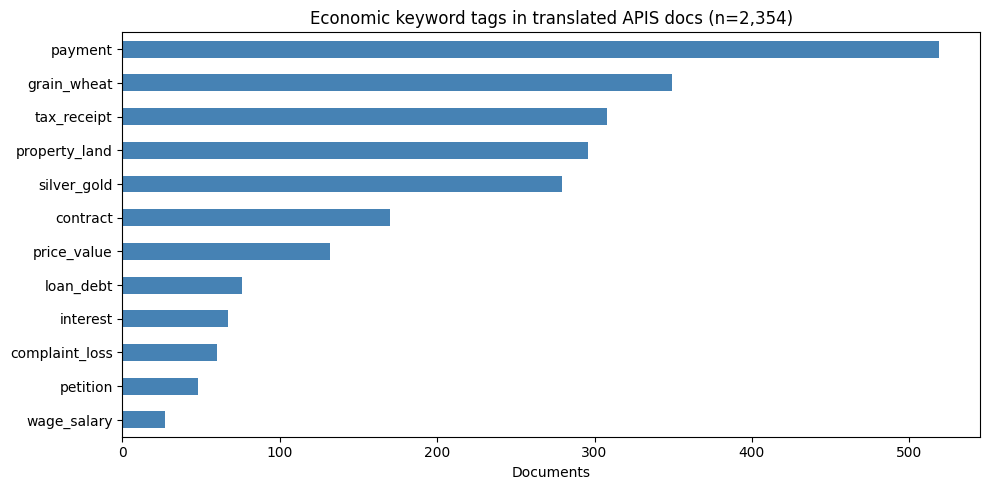

payment           519
grain_wheat       349
tax_receipt       308
property_land     296
silver_gold       279
contract          170
price_value       132
loan_debt          76
interest           67
complaint_loss     60
petition           48
wage_salary        27

Any economic tag: 1,120


In [5]:
ECON_PATTERNS = {
    'tax_receipt':   r'\btax\b|\btaxes\b|\breceipt[s]?\b|\btribute\b|\barithmesis\b',
    'payment':       r'\bpay(?:ment[s]?|\b|ing|able)|\bpaid\b|\bdisburs',
    'grain_wheat':   r'\bgrain\b|\bwheat\b|\bartaba[e]?\b|\bartal\b|\bbarley\b',
    'loan_debt':     r'\bloan[s]?\b|\bdebt[s]?\b|\bborrow|\bcreditor\b|\bdebtor\b',
    'price_value':   r'\bprice[sd]?\b|\bcost[sd]?\b|\bworth\b|\bvalue[sd]?\b',
    'interest':      r'\binterest\b|\busury\b|\brate\b',
    'contract':      r'\bcontract[s]?\b|\bagreement[s]?\b|\blease[s]?\b|\bsale[s]?\b',
    'silver_gold':   r'\bsilver\b|\bgold\b|\bdrachm[ae]?\b|\btalent[s]?\b|\bdenarii\b',
    'complaint_loss':r'\bcomplaint[s]?\b|\bcomplain\b|\bwrong(?:ed)?\b|\bloss\b|\bdamage[sd]?\b|\binjur',
    'petition':      r'\bpetition[s]?\b|\bappeal[s]?\b|\bsupplicate\b',
    'wage_salary':   r'\bwage[s]?\b|\bsalar[yi]\b|\bstipend\b|\bhire[d]?\b|\bworkman\b',
    'property_land': r'\bproperty\b|\bland\b|\bestate[s]?\b|\baroura[e]?\b|\bfield[s]?\b',
}

t = translated['translation_text'].fillna('')
for tag, pattern in ECON_PATTERNS.items():
    translated.loc[:, tag] = t.str.contains(pattern, case=False, regex=True)

tag_counts = {tag: translated[tag].sum() for tag in ECON_PATTERNS}
tag_df = pd.Series(tag_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
tag_df.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Documents')
ax.set_title(f'Economic keyword tags in translated APIS docs (n={len(translated):,})')
plt.tight_layout()
plt.show()

print(tag_df.to_string())
print(f'\nAny economic tag: {translated[list(ECON_PATTERNS.keys())].any(axis=1).sum():,}')

## 5. Complaint and loss framing (loss aversion signal)

In [6]:
complaints = translated[translated['complaint_loss']].copy()
print(f'Complaint/loss docs: {len(complaints):,}')
print()

# Show sample
sample = complaints[['doc_id','institution','title','date_year_approx','translation_text']].head(10)
for _, row in sample.iterrows():
    yr = f"{abs(int(row.date_year_approx))} {'BCE' if row.date_year_approx < 0 else 'CE'}" if pd.notna(row.date_year_approx) else 'undated'
    print(f"--- {row.doc_id} ({row.institution}, {yr}) ---")
    print(f"Title: {row.title}")
    text = str(row.translation_text)[:400]
    print(f"Text: {text}")
    print()

Complaint/loss docs: 60

--- berkeley.apis.110 (berkeley, undated) ---
Title: Account of oil
Text: Remainder carried to Mesore 143 1/2 1/12 1/24 artabas. In Mesore we received nothing. In Thoth from Touphis 500 art., from which deduct 7 per cent for loss in cleansing, making 32 2/3 art., leaving 467 1/3 art. Of clean sesame by the 30-choinix measure, which makes with what was carried forward 6101/2 1/3 1/12 1/24 art. Of this there was manufactured in Mesore 88 art., in Thoth 188 art., total 276

--- berkeley.apis.113 (berkeley, undated) ---
Title: Petition : draft
Text: ... to release them and the guarantors from the deficit. Wherefore at that time they were released from jail (canceled: but the), and the guarantors. After this, Alexander the (canceled: ta(x-)) official in charge of the tax farmers, (canceled: now deceased), lodged a complaint against me, without petition, with Argeios the epimeletes in the year 25, Mesore, fallaciously ... me immediately to depo

--- berkeley.apis.141

## 6. Grain prices over time

In [7]:
# Extract numeric amounts near artaba/grain mentions
# Pattern: number + drachmai/drachmas/dr near artaba/wheat/grain
grain_docs = translated[translated['grain_wheat'] & translated['silver_gold']].copy()
print(f'Grain + monetary docs: {len(grain_docs):,}')

# Extract price patterns: "N drachm" or "N artabas for N drachmai"
def extract_drachma_amounts(text):
    """Extract numeric values preceding drachma mentions."""
    if not isinstance(text, str):
        return []
    # e.g. "56 drachmai", "1 drachme", "100 dr."
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*(?:drachm[ae]?i?|dr\.)', text, re.IGNORECASE)
    return [float(m) for m in matches if float(m) < 10000]

grain_docs['drachma_amounts'] = grain_docs['translation_text'].apply(extract_drachma_amounts)
grain_docs['has_amounts'] = grain_docs['drachma_amounts'].apply(len) > 0

print(f'Grain+monetary with extractable amounts: {grain_docs["has_amounts"].sum():,}')
grain_docs[grain_docs.has_amounts][['doc_id','institution','date_year_approx','title','translation_text']].head(5)

Grain + monetary docs: 41
Grain+monetary with extractable amounts: 18


,doc_id,institution,date_year_approx,title,translation_text
265,berkeley.apis.102,berkeley,NaN,Register of land,"... land leased for copper money by Chairemon, one of the diadochi and epimeletes, 390 1/16 1/32 arouras, of which 30 arouras belong to the land leased for grain, yielding, at 1 artaba, 30 artabas..."
388,berkeley.apis.214,berkeley,NaN,Sale of Wheat,"(Abstract) The 22nd year, Choiak 9. Have sold Dionysios also called Petosiris son of Theon also called Thonis, Perses of the Epigone, and his wife Athenais also called Athermouthis daughter of Apo..."
401,berkeley.apis.226,berkeley,NaN,Settlement of a debt,"(5th h.) Registered in the 6th year, Mecheir 29: 5 copies were issued, one to each one. (1st h.) The sixth year of Imperator Caesar Lucius Septimius Severus Pius Pertinax Augustus Arabicus Adiaben..."
484,berkeley.apis.300,berkeley,NaN,Lease of land : signed by lessee,"To Aurelius Sarapammon, who is past his prime, and Aurelia Heraklia acting without a guardian, both children of Heron, from �is, Sarapammon having as curatrix his sister the aforesaid Heraklia, fr..."
610,berkeley.apis.415,berkeley,NaN,Application for the purchase of a priestly office : copy,"Copy. To Tiberius Claudius Justus, administrator of the private accounts, from Pakebkis son of Marsisouchos, exempted priest from the famous temple of Soknebtunis also called Kronos and the most g..."


## 7. Interest rates in loan documents

In [8]:
loan_docs = translated[translated['loan_debt']].copy()
print(f'Loan/debt docs: {len(loan_docs):,}')
print()

# Extract interest rate mentions: "N percent" or "N/12" style
def extract_interest(text):
    if not isinstance(text, str):
        return []
    # e.g. "interest at 12 percent", "at one percent per month", "at 8 drachmai per mina per month"
    pct = re.findall(r'(\d+(?:\.\d+)?)\s*(?:percent|%|per cent)', text, re.IGNORECASE)
    return [float(p) for p in pct]

loan_docs['interest_rates'] = loan_docs['translation_text'].apply(extract_interest)
all_rates = [r for rates in loan_docs['interest_rates'] for r in rates]
print(f'Interest rate mentions: {len(all_rates)}')
if all_rates:
    print(f'Rates: {sorted(all_rates)}')

print()
print('=== Sample loan documents ===')
for _, row in loan_docs.head(5).iterrows():
    yr = f"{abs(int(row.date_year_approx))} {'BCE' if row.date_year_approx < 0 else 'CE'}" if pd.notna(row.date_year_approx) else 'undated'
    print(f"\n{row.doc_id} ({row.institution}, {yr}) — {row.title}")
    print(str(row.translation_text)[:500])

Loan/debt docs: 76

Interest rate mentions: 1
Rates: [50.0]

=== Sample loan documents ===

berkeley.apis.117 (berkeley, 187 BCE) — Correspondence concerning a sitologos
Alexandros to Philon, greeting. Below is a copy of a letter to my agent Aniketos. You will accordingly do well to issue orders yourself that the persons are not to be molested before I arrive and give their statements proper attention. Goodbye. The 19th year, Pha... To Aniketos. Below is a copy of the memorandum presented to me by Ammonios, Sitologos of Boubastos in the division of Herakleides. Let safe-conducts be given to the persons specified and let them remain at the duty assigned to them u

berkeley.apis.139 (berkeley, undated) — Repayment of a loan
... in the month of Mesore ... Sarapias, without legal father, her mother being ... [about] ..-seven [years old] with a scar on the right knee, with her guardian ... [about] ..-five [years old] with a scar on the left shin, agrees with Achilles ... of Arsinoiton polis

## 8. Tax receipt patterns — payment amounts and compliance framing

Tax/receipt docs: 308



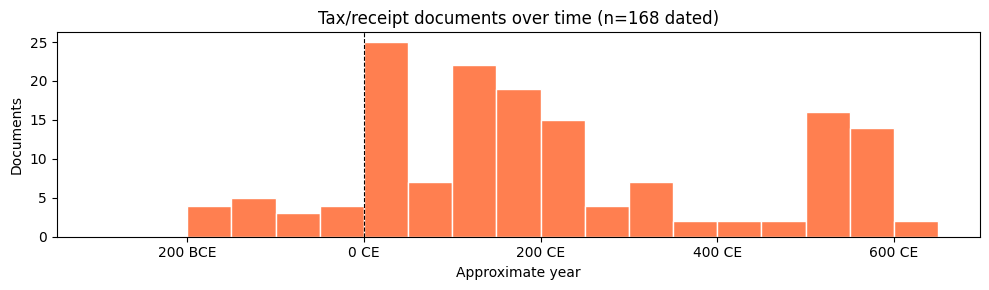

institution
berkeley     96
chicago      45
princeton    36
petra        30
oslo         26
michigan     19
wisconsin    14
hermitage    13


In [9]:
tax_docs = translated[translated['tax_receipt']].copy()
print(f'Tax/receipt docs: {len(tax_docs):,}')
print()

# Temporal distribution of tax docs
tax_dated = tax_docs[tax_docs.date_year_approx.notna()].copy()
tax_dated['date_year_approx'] = tax_dated['date_year_approx'].astype(int)

fig, ax = plt.subplots(figsize=(10,3))
bins = range(-300, 700, 50)
ax.hist(tax_dated['date_year_approx'], bins=bins, color='coral', edgecolor='white')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Approximate year')
ax.set_ylabel('Documents')
ax.set_title(f'Tax/receipt documents over time (n={len(tax_dated):,} dated)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x))} {"BCE" if x < 0 else "CE"}'))
plt.tight_layout()
plt.show()

# Institution breakdown
print(tax_docs['institution'].value_counts().head(8).to_string())

## 9. Named agents — recurring individuals across documents

In [10]:
# Look for recurring personal names in michigan tax receipts
mich_tax = translated[(translated.institution == 'michigan') & translated['tax_receipt']].copy()
print(f'Michigan tax docs: {len(mich_tax):,}')

# Extract names — look for "son of" patterns to find individual agents
all_names = []
for text in mich_tax['translation_text'].dropna():
    # Pattern: "Name, son of Name" or just capitalize words before 'son of'
    matches = re.findall(r'([A-Z][a-z]+(?:\s[A-Z][a-z]+)?),?\s+son of', text)
    all_names.extend(matches)

name_counts = Counter(all_names)
print('\nMost frequent named agents in Michigan tax docs:')
for name, count in name_counts.most_common(20):
    print(f'  {name}: {count}')

Michigan tax docs: 19

Most frequent named agents in Michigan tax docs:
  Horos: 3
  Pamonthis: 1
  Germanus: 1
  Sarapion: 1
  Mendes: 1
  Numissius: 1
  Nikon: 1
  Nemesas: 1
  Neraus: 1
  Ousebas: 1
  Panetb: 1
  Pamoutis: 1
  Mysthes: 1
  Haryotes: 1
  Palaomis: 1
  Papees: 1
  Apis: 1


## 10. Behavioral signal summary

In [11]:
print('=== BEHAVIORAL ECONOMICS SIGNAL ASSESSMENT ===')
print()
print('CORPUS SIZE')
print(f'  Total APIS docs:          {len(apis):,}')
print(f'  Translated:               {apis["has_translation"].sum():,} ({100*apis["has_translation"].mean():.0f}%)')
print(f'  Date range:               ~300 BCE to ~700 CE')
print(f'  Primary language:         Greek (88%), Demotic (7%), Coptic (3%)')
print()
print('ECONOMIC CONTENT')
for tag, count in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f'  {tag:20s}: {count:,} docs')
print()
print('BEHAVIORAL SIGNALS')
print(f'  Loss/complaint framing:   {translated["complaint_loss"].sum():,} docs — test loss aversion framing')
print(f'  Loan/interest docs:       {translated["loan_debt"].sum():,} docs — test interest rate expectations')
print(f'  Price mentions:           {translated["price_value"].sum():,} docs — test price anchoring')
print(f'  Grain prices:             {translated["grain_wheat"].sum():,} docs — commodity price series')
print(f'  Tax compliance:           {translated["tax_receipt"].sum():,} docs — compliance framing')
print(f'  Petitions/appeals:        {translated["petition"].sum():,} docs — escalation/persistence')
print()
print('NEXT STEPS')
print('  1. Extract price series from grain/commodity docs and test for anchoring')
print('  2. Code complaint docs for gain vs. loss framing (prospect theory)')
print('  3. Extract interest rates from loan docs — compare to theoretical risk-free rates')
print('  4. Track named agents across michigan docs for network/reputation effects')
print('  5. Join with P.Oxy transcriptions for fuller coverage')

=== BEHAVIORAL ECONOMICS SIGNAL ASSESSMENT ===

CORPUS SIZE
  Total APIS docs:          9,832
  Translated:               2,354 (24%)
  Date range:               ~300 BCE to ~700 CE
  Primary language:         Greek (88%), Demotic (7%), Coptic (3%)

ECONOMIC CONTENT
  payment             : 519 docs
  grain_wheat         : 349 docs
  tax_receipt         : 308 docs
  property_land       : 296 docs
  silver_gold         : 279 docs
  contract            : 170 docs
  price_value         : 132 docs
  loan_debt           : 76 docs
  interest            : 67 docs
  complaint_loss      : 60 docs
  petition            : 48 docs
  wage_salary         : 27 docs

BEHAVIORAL SIGNALS
  Loss/complaint framing:   60 docs — test loss aversion framing
  Loan/interest docs:       76 docs — test interest rate expectations
  Price mentions:           132 docs — test price anchoring
  Grain prices:             349 docs — commodity price series
  Tax compliance:           308 docs — compliance framing
  Petit